# Análisis Perfil Cliente

- Responder a la pregunta de negocio:

#### Quins són els perfils demogràfics que mostren més propensió a contractar productes financers?

In [13]:
# LIBRERIAS
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

### CARAGAR FICHERO .CSV

In [16]:
data_path = r"C:\\LLUIS\Dropbox\\IT ACADEMY\Simulacio Empresarial Docs\\BBDD_bank.csv"

In [25]:
# Cargar el dataset con separador y encoding correctos
df = pd.read_csv(
    data_path,
    sep=",",
    encoding="utf-8"
)

df.head()

,id,age,job,marital,education,credit_default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59.0,admin.,married,secondary,0,2343,1,0,unknown,5,may,1042,1,-1,0,unknown,1
1,2,59.0,admin.,married,secondary,0,2343,1,0,unknown,5,may,1042,1,-1,0,unknown,1
2,3,56.0,admin.,married,secondary,0,45,0,0,unknown,5,may,1467,1,-1,0,unknown,1
3,4,41.0,technician,married,secondary,0,1270,1,0,unknown,5,may,1389,1,-1,0,unknown,1
4,5,55.0,services,married,secondary,0,2476,1,0,unknown,5,may,579,1,-1,0,unknown,1


### CARGAR BBDD MYSQL

In [20]:
# pasamos la tabla a un DataFrame de pandas
import mysql.connector
import pandas as pd

connection = mysql.connector.connect(
    host="212.227.90.6",
    user="Equipo21",
    password="E1q2u3i4p5o21",
    database="Equip_21",  # <-- obligatorio
    port=3306                     # puerto por defecto MySQL
)

df = pd.read_sql("SELECT * FROM BANK_marketing", connection)
df.head()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_60216\514717404.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM BANK_marketing", connection)


,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,2,59.0,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
2,3,56.0,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
3,4,41.0,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
4,5,55.0,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes


In [21]:
# prodcutos financieros
productos = ["deposit", "housing", "loan"]

## 1. Productos contratados según la edad

       deposit   housing      loan
age                               
18.0  0.875000  0.000000  0.000000
19.0  0.846154  0.000000  0.000000
20.0  0.789474  0.157895  0.000000
21.0  0.733333  0.066667  0.066667
22.0  0.833333  0.104167  0.083333


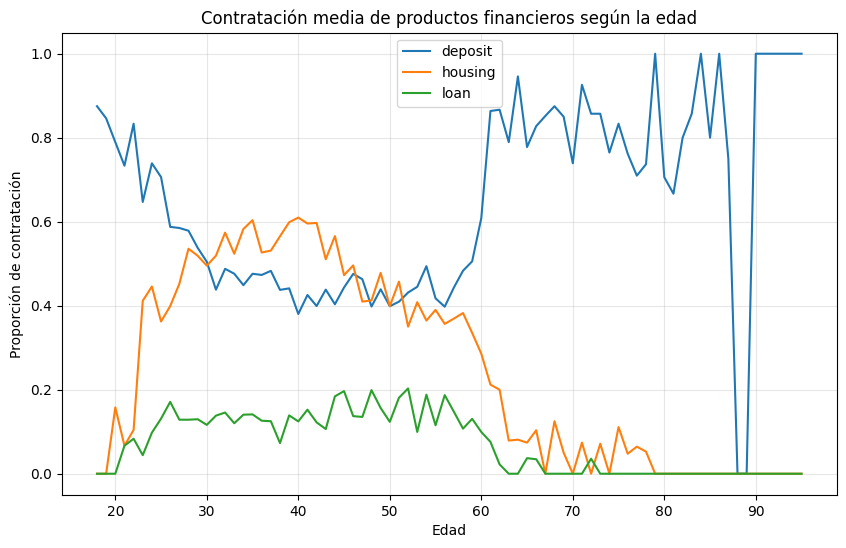

In [27]:
edad_productos = df.groupby('age')[productos].mean()#.reset_index().sort_values(by='age')  
edad_productos.plot(figsize=(10,6))
print(edad_productos.head())
plt.title("Contratación media de productos financieros según la edad")
plt.xlabel("Edad")
plt.ylabel("Proporción de contratación")
plt.grid(True,axis='both', alpha=0.3)
plt.show()


__Para cada edad:__

- % de clientes con depósito

- % con hipoteca

- % con préstamo personal

__Se observan patrones claros:__

- housing aumenta en edades intermedias

- loan es más frecuente en edades jóvenes-adultas

- deposit es estable (dataset ya filtrado a clientes contactadoS)

## 2. Productos contratados según profesión (job)

In [ ]:
df_filtrado = df[(df['deposit'] == 1) | (df['housing'] == 1) | (df['loan'] == 1)]
job_productos = df_filtrado.groupby('job')[productos].mean().sort_values("deposit", ascending=False)
print(job_productos)
job_productos.plot(kind='bar', stacked=False, colormap='viridis', figsize=(10,6))
plt.title("Contratación de productos financieros según profesión")
plt.xlabel("Profesión")
plt.ylabel("Proporción de contratación")
plt.xticks(rotation=45, ha="right")
plt.show()

 ### Barras acumuladas de contratación por tipo de trabajo

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Crear las tablas cruzadas
deposit_ct = pd.crosstab(df['job'], df['deposit'])
deposit_ct = deposit_ct.sort_values(by=1, ascending=False)
loan_ct = pd.crosstab(df['job'], df['loan'])
loan_ct = loan_ct.sort_values(by=1, ascending=False)
housing_ct = pd.crosstab(df['job'], df['housing'])
housing_ct = housing_ct.sort_values(by=1, ascending=False)

print(deposit_ct.head(12))
print("-----    -----")
print(loan_ct.head(12))  
print("-----    -----") 
print(housing_ct.head(12))
# Plot anidado simple
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Gráfico 1
deposit_ct.plot(kind='bar', stacked=True, ax=axes[0], colormap='RdYlGn')
axes[0].set_title('Depósito')
axes[0].set_xlabel('')
axes[0].legend(loc='upper right')
axes[0].xaxis.set_tick_params(rotation=45)

# Gráfico 2
loan_ct.plot(kind='bar', stacked=True, ax=axes[1], colormap='RdYlGn')
axes[1].set_title('Préstamo')
axes[1].set_xlabel('')
axes[1].legend(loc='upper right')
axes[1].xaxis.set_tick_params(rotation=45)

# Gráfico 3
housing_ct.plot(kind='bar', stacked=True, ax=axes[2], colormap='RdYlGn')
axes[2].set_title('Vivienda')
axes[2].set_xlabel('Ocupación')
axes[2].legend(loc='upper right')
axes[2].xaxis.set_tick_params(rotation=45)

plt.suptitle('Análisis de Variables por Ocupación', fontsize=14)
plt.tight_layout()
plt.show()

__Interpretación__

- Profesiones con mas contrataciones en hipotecas(housing): blue-collar, managament,technician, admin y services.

- Profesiones con mas contrataciones en préstamo personal(loan): blue-collar, managament,technician, admin y services.

- Profesiones con mas contrataciones depositos(deposit): managament,technician, blue-collar, admin y retired.

__Observación__

Las cinco primeras posiciones estan ocupadas por las mismas profesiones excepto la de depositos que no aparece services pero si retired. Esto puede deberse a que los jubilados contratan más depositos de ahorro debido a su jubilación.

### HEADMAP PORCENTUAL POR COLUMNA

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
print(pd.crosstab(df['job'], df['deposit'], normalize='columns')[1] * 100)
print(df.groupby('job')[['deposit']].mean()   * 100)

# Calcular porcentaje por columna (para cada producto, distribución de los 1's por ocupación)
percent_by_col = pd.concat([
    pd.crosstab(df['job'], df['deposit'], normalize='columns')[1] * 100
    #pd.crosstab(df['job'], df['loan'], normalize='columns')[1] * 100,
    #pd.crosstab(df['job'], df['housing'], normalize='columns')[1] * 100
], axis=1)

percent_by_col.columns = ['Deposit'] #, 'Loan', 'Housing']

# Ordenar por Deposit (puedes cambiar a 'Loan' o 'Housing')
percent_by_col = percent_by_col.sort_values('Deposit', ascending=False)
print(percent_by_col)
# Crear heatmap simple
plt.figure(figsize=(10, 8))
sns.heatmap(percent_by_col, 
            annot=True, 
            fmt='.1f', 
            cmap='Blues',
            linewidths=0.5,
            linecolor='gray')

plt.title('Distribución porcentual de contratción por Ocupación', fontweight='bold')
plt.xlabel('Producto')
plt.ylabel('Ocupación')
plt.tight_layout()
plt.show()

# Mostrar los datos
print("Porcentaje por columna (cada columna suma 100%):")
print(percent_by_col.round(1))

### DISTRIBUCION DE % SEPARADO X PRODUCTO

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular porcentaje por columna (para cada producto, distribución de los 1's por ocupación)
percent_by_col = pd.concat([
    pd.crosstab(df['job'], df['deposit'], normalize='columns')[1] * 100,
    pd.crosstab(df['job'], df['loan'], normalize='columns')[1] * 100,
    pd.crosstab(df['job'], df['housing'], normalize='columns')[1] * 100
], axis=1)

percent_by_col.columns = ['Deposit', 'Loan', 'Housing']

# Ordenar por Deposit (puedes cambiar a 'Loan' o 'Housing')
percent_by_col = percent_by_col.sort_values('Deposit', ascending=True)  # Cambiado a True para mejor visualización en barras

# Crear figura con 3 subplots (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(18, 10))
fig.suptitle('Distribución porcentual de contratación por Ocupación', fontsize=16, fontweight='bold', y=1.02)

# Colores para cada producto
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Crear gráfico de barras horizontales para cada producto
for idx, (col, color) in enumerate(zip(['Deposit', 'Loan', 'Housing'], colors)):
    ax = axes[idx]
    
    # Gráfico de barras horizontales
    bars = ax.barh(percent_by_col.index, percent_by_col[col], color=color, edgecolor='black')
    
    # Añadir etiquetas con los valores
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{width:.1f}%', va='center', fontsize=9)
    
    # Configurar cada subplot
    ax.set_title(f'{col} - % por Ocupación', fontweight='bold', pad=12)
    ax.set_xlabel('Porcentaje (%)')
    ax.set_xlim(0, percent_by_col[col].max() * 1.2)  # Añadir margen para las etiquetas
    
    # Solo mostrar etiquetas del eje Y en el primer gráfico
    if idx > 0:
        ax.set_ylabel('')
        ax.set_yticklabels([])
    else:
        ax.set_ylabel('Ocupación')

# Ajustar layout
plt.tight_layout()
plt.show()

# Mostrar los datos en formato de tabla
print("=" * 70)
print("PORCENTAJE DE CONTRATACIÓN POR OCUPACIÓN Y PRODUCTO")
print("=" * 70)
print(percent_by_col.sort_values('Deposit', ascending=False).round(1))
print("\nNota: Cada columna suma 100% (distribución de contrataciones por ocupación)")

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular porcentaje por columna (para cada producto, distribución de los 1's por ocupación)
percent_by_col = pd.concat([
    pd.crosstab(df['job'], df['deposit'], normalize='columns')[1] * 100,
    pd.crosstab(df['job'], df['loan'], normalize='columns')[1] * 100,
    pd.crosstab(df['job'], df['housing'], normalize='columns')[1] * 100
], axis=1)

percent_by_col.columns = ['Deposit', 'Loan', 'Housing']

# Crear figura con 3 subplots (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(20, 12))
fig.suptitle('Distribución porcentual de contratación por Ocupación\n(Cada columna suma 100%)', 
             fontsize=16, fontweight='bold', y=1.02)

# Colores para cada producto
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Para cada producto, crear gráfico ordenado independientemente
for idx, (col, color) in enumerate(zip(['Deposit', 'Loan', 'Housing'], colors)):
    ax = axes[idx]
    
    # Ordenar este producto específico de mayor a menor
    data_sorted = percent_by_col[col].sort_values(ascending=True)  # True para barras horizontales
    
    # Gráfico de barras horizontales
    bars = ax.barh(data_sorted.index, data_sorted, color=color, edgecolor='black', alpha=0.8)
    
    # Añadir etiquetas con los valores
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.3, bar.get_y() + bar.get_height()/2, 
                f'{width:.1f}%', va='center', fontsize=9, fontweight='bold')
    
    # Configurar cada subplot
    ax.set_title(f'{col} - Distribución de contrataciones\n(Ordenado por % descendente)', 
                 fontweight='bold', pad=15, fontsize=13)
    ax.set_xlabel('Porcentaje del total de contrataciones (%)', fontsize=11)
    ax.set_ylabel('Ocupación', fontsize=11)
    
    # Ajustar límites del eje X con margen para etiquetas
    max_value = data_sorted.max()
    ax.set_xlim(0, max_value * 1.25)
    
    # Mostrar todas las etiquetas de ocupación
    ax.set_yticks(range(len(data_sorted.index)))
    ax.set_yticklabels(data_sorted.index, fontsize=10)
    
    # Añadir líneas de cuadrícula
    ax.grid(True, axis='x', alpha=0.3, linestyle='--')
    
    # Añadir anotación del total
    total = percent_by_col[col].sum()
    ax.text(0.98, 0.02, f'Total: {total:.0f}%', 
             transform=ax.transAxes, fontsize=10, 
             verticalalignment='bottom', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Ajustar layout
plt.tight_layout()
plt.show()

# Mostrar los datos en formato de tabla con ordenamientos independientes
print("=" * 90)
print("DISTRIBUCIÓN PORCENTUAL POR OCUPACIÓN Y PRODUCTO")
print("Cada columna suma 100% (distribución de contrataciones del producto por ocupación)")
print("=" * 90)

# Mostrar cada tabla ordenada por su propio producto
products = ['Deposit', 'Loan', 'Housing']
for product in products:
    print(f"\n{product.upper()} - Ordenado por % descendente:")
    print("-" * 50)
    sorted_data = percent_by_col[product].sort_values(ascending=False)
    for idx, (ocupacion, valor) in enumerate(sorted_data.items(), 1):
        print(f"{idx:2d}. {ocupacion:15s}: {valor:6.1f}%")
    
    # Mostrar estadísticas
    print(f"\n  Estadísticas: Max={sorted_data.max():.1f}%, Min={sorted_data.min():.1f}%, "
          f"Media={sorted_data.mean():.1f}%, Mediana={sorted_data.median():.1f}%")

print("\n" + "=" * 90)
print("RESUMEN COMPARATIVO - TOP 3 DE CADA PRODUCTO")
print("=" * 90)

for product in products:
    top3 = percent_by_col[product].nlargest(3)
    print(f"\n{product}:")
    for idx, (ocupacion, valor) in enumerate(top3.items(), 1):
        print(f"  {idx}. {ocupacion:15s}: {valor:5.1f}%")

### Distribución Porcentual por Ocupación (Ordenado por % de Contratación de cada ocupación)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Crear tablas cruzadas normalizadas (porcentajes por fila)
deposit_pct = pd.crosstab(df['job'], df['deposit'], normalize='index') * 100
loan_pct = pd.crosstab(df['job'], df['loan'], normalize='index') * 100
housing_pct = pd.crosstab(df['job'], df['housing'], normalize='index') * 100

# Ordenar cada tabla por la columna 1 (Sí/Contratado) de mayor a menor
deposit_pct = deposit_pct.sort_values(1, ascending=False)
loan_pct = loan_pct.sort_values(1, ascending=False)
housing_pct = housing_pct.sort_values(1, ascending=False)

# Plot anidado
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# Gráficos de barras apiladas con porcentajes
deposit_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2')
loan_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set3')
housing_pct.plot(kind='bar', stacked=True, ax=axes[2], colormap='Set1')

# Configuración común
titles = ['Depósito (%)', 'Préstamo (%)', 'Vivienda (%)']
colors = ['#FF6B6B', '#4ECDC4']  # Rojo para No, Verde para Sí

for i, ax in enumerate(axes):
    ax.set_title(titles[i], fontweight='bold', fontsize=14, pad=15)
    ax.set_xlabel('Ocupación', fontsize=12)
    ax.set_ylabel('Porcentaje (%)', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='', labels=['No', 'Sí'], bbox_to_anchor=(1.02, 1), borderaxespad=0)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 100])  # Asegurar que el eje Y vaya de 0 a 100%
    
    # Añadir etiquetas de porcentaje en las barras (solo para la parte de "Sí")
    for container in ax.containers:
        # Solo mostrar etiqueta si el valor es mayor a 5% para evitar superposición
        for bar in container:
            height = bar.get_height()
            if height > 5:  # Mostrar solo si el segmento es suficientemente grande
                ax.text(bar.get_x() + bar.get_width()/2, 
                       bar.get_y() + height/2, 
                       f'{height:.1f}%', 
                       ha='center', va='center', fontsize=9, fontweight='bold')

# Añadir título principal
plt.suptitle('Distribución Porcentual por Ocupación (Ordenado por % de Contratación)', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# Mostrar tablas ordenadas
print("=" * 100)
print("TABLAS ORDENADAS POR PORCENTAJE DE CONTRATACIÓN (SÍ)")
print("=" * 100)

print("\n1. DEPÓSITO - Ordenado por % de contratación (Sí):")
print(deposit_pct.round(1).rename(columns={0: 'No', 1: 'Sí'}))

print("\n2. PRÉSTAMO - Ordenado por % de contratación (Sí):")
print(loan_pct.round(1).rename(columns={0: 'No', 1: 'Sí'}))

print("\n3. VIVIENDA - Ordenado por % de contratación (Sí):")
print(housing_pct.round(1).rename(columns={0: 'No', 1: 'Sí'}))

# Mostrar ranking top 3 para cada producto
print("\n" + "=" * 100)
print("RANKING TOP 3 POR PRODUCTO")
print("=" * 100)

for name, data, product in [('DEPÓSITO', deposit_pct, 1), 
                            ('PRÉSTAMO', loan_pct, 1), 
                            ('VIVIENDA', housing_pct, 1)]:
    print(f"\n{name}:")
    top3 = data.nlargest(3, 1)
    for idx, (ocupacion, row) in enumerate(top3.iterrows(), 1):
        print(f"  {idx}. {ocupacion}: {row[1]:.1f}% de contratación")

## 3. Productos contratados según estado civil (marital)

In [ ]:
df_filtrado = df[(df['deposit'] == 1) | (df['housing'] == 1) | (df['loan'] == 1)]
df_filtrado = df_filtrado[(df['marital'] != 'unknown')]
marital_productos = df_filtrado.groupby("marital")[["deposit", "housing", "loan"]].mean()
print(marital_productos)
marital_productos.plot(kind="bar",figsize=(10,6),colormap='viridis')
plt.title("Contratación de productos financieros según estado civil")
plt.xlabel("Estado civil")
plt.ylabel("Proporción de contratación")
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.show()


### GRAFICOS DIVIDIDO x ESTADO CIVIL

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Crear las tablas cruzadas
deposit_ct = pd.crosstab(df['marital'], df['deposit'])
deposit_ct = deposit_ct.sort_values(by=1, ascending=False)
loan_ct = pd.crosstab(df['marital'], df['loan'])
loan_ct = loan_ct.sort_values(by=1, ascending=False)
housing_ct = pd.crosstab(df['marital'], df['housing'])
housing_ct = housing_ct.sort_values(by=1, ascending=False)

print(deposit_ct.head())
print("-----    -----")
print(loan_ct.head())  
print("-----    -----") 
print(housing_ct.head())
# Plot anidado simple
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Gráfico 1
deposit_ct.plot(kind='bar', stacked=True, ax=axes[0], colormap='RdYlGn')
axes[0].set_title('Depósito')
axes[0].set_xlabel('')
axes[0].legend(loc='upper right')
axes[0].xaxis.set_tick_params(rotation=45)

# Gráfico 2
loan_ct.plot(kind='bar', stacked=True, ax=axes[1], colormap='RdYlGn')
axes[1].set_title('Préstamo')
axes[1].set_xlabel('')
axes[1].legend(loc='upper right')
axes[1].xaxis.set_tick_params(rotation=45)

# Gráfico 3
housing_ct.plot(kind='bar', stacked=True, ax=axes[2], colormap='RdYlGn')
axes[2].set_title('Vivienda')
axes[2].set_xlabel('Ocupación')
axes[2].legend(loc='upper right')
axes[2].xaxis.set_tick_params(rotation=45)

plt.suptitle('Análisis de Variables por Ocupación', fontsize=14)
plt.tight_layout()
plt.show()

### HEADMAP % PRO COLUMNA

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular porcentaje por columna (para cada producto, distribución de los 1's por ocupación)
percent_by_col = pd.concat([
    pd.crosstab(df_filtrado['marital'], df['deposit'], normalize='columns')[1] * 100,
    pd.crosstab(df_filtrado['marital'], df['loan'], normalize='columns')[1] * 100,
    pd.crosstab(df_filtrado['marital'], df['housing'], normalize='columns')[1] * 100
], axis=1)

percent_by_col.columns = ['Deposit', 'Loan', 'Housing']

# Ordenar por Deposit (puedes cambiar a 'Loan' o 'Housing')
percent_by_col = percent_by_col.sort_values('Deposit', ascending=False)

# Crear heatmap simple
plt.figure(figsize=(10, 8))
sns.heatmap(percent_by_col, 
            annot=True, 
            fmt='.1f', 
            cmap='Blues',
            linewidths=0.5,
            linecolor='gray')

plt.title('Distribución porcentual de contratción por Ocupación', fontweight='bold')
plt.xlabel('Producto')
plt.ylabel('Ocupación')
plt.tight_layout()
plt.show()

# Mostrar los datos
print("Porcentaje por columna (cada columna suma 100%):")
print(percent_by_col.round(1))

# Disrtibución del % del procuto por estado civil

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular porcentaje por columna (para cada producto, distribución de los 1's por ocupación)
percent_by_col = pd.concat([
    pd.crosstab(df_filtrado['marital'], df['deposit'], normalize='columns')[1] * 100,
    pd.crosstab(df_filtrado['marital'], df['loan'], normalize='columns')[1] * 100,
    pd.crosstab(df_filtrado['marital'], df['housing'], normalize='columns')[1] * 100
], axis=1)

percent_by_col.columns = ['Deposit', 'Loan', 'Housing']

# Ordenar por Deposit (puedes cambiar a 'Loan' o 'Housing')
percent_by_col = percent_by_col.sort_values('Deposit', ascending=True)  # Cambiado a True para mejor visualización en barras

# Crear figura con 3 subplots (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(18, 10))
fig.suptitle('Distribución porcentual de contratación por Ocupación', fontsize=16, fontweight='bold', y=1.02)

# Colores para cada producto
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Crear gráfico de barras horizontales para cada producto
for idx, (col, color) in enumerate(zip(['Deposit', 'Loan', 'Housing'], colors)):
    ax = axes[idx]
    
    # Gráfico de barras horizontales
    bars = ax.barh(percent_by_col.index, percent_by_col[col], color=color, edgecolor='black')
    
    # Añadir etiquetas con los valores
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{width:.1f}%', va='center', fontsize=9)
    
    # Configurar cada subplot
    ax.set_title(f'{col} - % por Ocupación', fontweight='bold', pad=12)
    ax.set_xlabel('Porcentaje (%)')
    ax.set_xlim(0, percent_by_col[col].max() * 1.2)  # Añadir margen para las etiquetas
    
    # Solo mostrar etiquetas del eje Y en el primer gráfico
    if idx > 0:
        ax.set_ylabel('')
        ax.set_yticklabels([])
    else:
        ax.set_ylabel('Ocupación')

# Ajustar layout
plt.tight_layout()
plt.show()

# Mostrar los datos en formato de tabla
print("=" * 70)
print("PORCENTAJE DE CONTRATACIÓN POR OCUPACIÓN Y PRODUCTO")
print("=" * 70)
print(percent_by_col.sort_values('Deposit', ascending=False).round(1))
print("\nNota: Cada columna suma 100% (distribución de contrataciones por ocupación)")

__Interpretación__

- married:

mayor peso en housing, loan i deposit

- single:

más equilibrio entre productos

Variable muy relevante para estrategias de crédito e hipoteca

### Distribucion porcentual por tipo de estado civil

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Crear tablas cruzadas normalizadas (porcentajes por fila)
deposit_pct = pd.crosstab(df_filtrado['marital'], df['deposit']) * 100
loan_pct = pd.crosstab(df_filtrado['marital'], df['loan']) * 100
housing_pct = pd.crosstab(df_filtrado['marital'], df['housing']) * 100

# Ordenar cada tabla por la columna 1 (Sí/Contratado) de mayor a menor
deposit_pct = deposit_pct.sort_values(1, ascending=False)
loan_pct = loan_pct.sort_values(1, ascending=False)
housing_pct = housing_pct.sort_values(1, ascending=False)

# Plot anidado
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# Gráficos de barras apiladas con porcentajes
deposit_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2')
loan_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set3')
housing_pct.plot(kind='bar', stacked=True, ax=axes[2], colormap='Set1')

# Configuración común
titles = ['Depósito (%)', 'Préstamo (%)', 'Vivienda (%)']
colors = ['#FF6B6B', '#4ECDC4']  # Rojo para No, Verde para Sí

for i, ax in enumerate(axes):
    ax.set_title(titles[i], fontweight='bold', fontsize=14, pad=15)
    ax.set_xlabel('Ocupación', fontsize=12)
    ax.set_ylabel('Porcentaje (%)', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='', labels=['No', 'Sí'], bbox_to_anchor=(1.02, 1), borderaxespad=0)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 100])  # Asegurar que el eje Y vaya de 0 a 100%
    
    # Añadir etiquetas de porcentaje en las barras (solo para la parte de "Sí")
    for container in ax.containers:
        # Solo mostrar etiqueta si el valor es mayor a 5% para evitar superposición
        for bar in container:
            height = bar.get_height()
            if height > 5:  # Mostrar solo si el segmento es suficientemente grande
                ax.text(bar.get_x() + bar.get_width()/2, 
                       bar.get_y() + height/2, 
                       f'{height:.1f}%', 
                       ha='center', va='center', fontsize=9, fontweight='bold')

# Añadir título principal
plt.suptitle('Distribución Porcentual por Ocupación (Ordenado por % de Contratación)', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# Mostrar tablas ordenadas
print("=" * 100)
print("TABLAS ORDENADAS POR PORCENTAJE DE CONTRATACIÓN (SÍ)")
print("=" * 100)

print("\n1. DEPÓSITO - Ordenado por % de contratación (Sí):")
print(deposit_pct.round(1).rename(columns={0: 'No', 1: 'Sí'}))

print("\n2. PRÉSTAMO - Ordenado por % de contratación (Sí):")
print(loan_pct.round(1).rename(columns={0: 'No', 1: 'Sí'}))

print("\n3. VIVIENDA - Ordenado por % de contratación (Sí):")
print(housing_pct.round(1).rename(columns={0: 'No', 1: 'Sí'}))

# Mostrar ranking top 3 para cada producto
print("\n" + "=" * 100)
print("RANKING TOP 3 POR PRODUCTO")
print("=" * 100)

for name, data, product in [('DEPÓSITO', deposit_pct, 1), 
                            ('PRÉSTAMO', loan_pct, 1), 
                            ('VIVIENDA', housing_pct, 1)]:
    print(f"\n{name}:")
    top3 = data.nlargest(3, 1)
    for idx, (ocupacion, row) in enumerate(top3.iterrows(), 1):
        print(f"  {idx}. {ocupacion}: {row[1]:.1f}% de contratación")

# 4. Productos contratados según nivel educativo (education)

In [ ]:
df_filtrado = df[(df['deposit'] == 1) | (df['housing'] == 1) | (df['loan'] == 1)]
marital_productos = df_filtrado.groupby("education")[["deposit", "housing", "loan"]].mean()

marital_productos.plot(kind="bar",figsize=(10,6),colormap='viridis')
plt.title("Contratación de productos financieros según estado civil")
plt.xlabel("Estado civil")
plt.ylabel("Proporción de contratación")
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.show()


### Barras por tipo de estudios por produto

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Crear las tablas cruzadas
deposit_ct = pd.crosstab(df['education'], df['deposit'])
deposit_ct = deposit_ct.sort_values(by=1, ascending=False)
loan_ct = pd.crosstab(df['education'], df['loan'])
loan_ct = loan_ct.sort_values(by=1, ascending=False)
housing_ct = pd.crosstab(df['education'], df['housing'])
housing_ct = housing_ct.sort_values(by=1, ascending=False)

print(deposit_ct.head())
print("-----    -----")
print(loan_ct.head())  
print("-----    -----") 
print(housing_ct.head())
# Plot anidado simple
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Gráfico 1
deposit_ct.plot(kind='bar', stacked=True, ax=axes[0], colormap='RdYlGn')
axes[0].set_title('Depósito')
axes[0].set_xlabel('')
axes[0].legend(loc='upper right')
axes[0].xaxis.set_tick_params(rotation=45)

# Gráfico 2
loan_ct.plot(kind='bar', stacked=True, ax=axes[1], colormap='RdYlGn')
axes[1].set_title('Préstamo')
axes[1].set_xlabel('')
axes[1].legend(loc='upper right')
axes[1].xaxis.set_tick_params(rotation=45)

# Gráfico 3
housing_ct.plot(kind='bar', stacked=True, ax=axes[2], colormap='RdYlGn')
axes[2].set_title('Vivienda')
axes[2].set_xlabel('Ocupación')
axes[2].legend(loc='upper right')
axes[2].xaxis.set_tick_params(rotation=45)

plt.suptitle('Análisis de Variables por Ocupación', fontsize=14)
plt.tight_layout()
plt.show()

### Headmap por columna

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular porcentaje por columna (para cada producto, distribución de los 1's por ocupación)
percent_by_col = pd.concat([
    pd.crosstab(df['education'], df['deposit'], normalize='columns')[1] * 100,
    pd.crosstab(df['education'], df['loan'], normalize='columns')[1] * 100,
    pd.crosstab(df['education'], df['housing'], normalize='columns')[1] * 100
], axis=1)

percent_by_col.columns = ['Deposit', 'Loan', 'Housing']

# Ordenar por Deposit (puedes cambiar a 'Loan' o 'Housing')
percent_by_col = percent_by_col.sort_values('Deposit', ascending=False)

# Crear heatmap simple
plt.figure(figsize=(10, 8))
sns.heatmap(percent_by_col, 
            annot=True, 
            fmt='.1f', 
            cmap='Blues',
            linewidths=0.5,
            linecolor='gray')

plt.title('Distribución porcentual de contratción por Ocupación', fontweight='bold')
plt.xlabel('Producto')
plt.ylabel('Ocupación')
plt.tight_layout()
plt.show()

# Mostrar los datos
print("Porcentaje por columna (cada columna suma 100%):")
print(percent_by_col.round(1))

### Distribución en % del nivel de estudios en barra laterales y columnas para la comparativa

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular porcentaje por columna (para cada producto, distribución de los 1's por ocupación)
percent_by_col = pd.concat([
    pd.crosstab(df_filtrado['education'], df['deposit'], normalize='columns')[1] * 100,
    pd.crosstab(df_filtrado['education'], df['loan'], normalize='columns')[1] * 100,
    pd.crosstab(df_filtrado['education'], df['housing'], normalize='columns')[1] * 100
], axis=1)

percent_by_col.columns = ['Deposit', 'Loan', 'Housing']

# Ordenar por Deposit (puedes cambiar a 'Loan' o 'Housing')
percent_by_col = percent_by_col.sort_values('Deposit', ascending=True)  # Cambiado a True para mejor visualización en barras

# Crear figura con 3 subplots (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(18, 10))
fig.suptitle('Distribución porcentual de contratación por Ocupación', fontsize=16, fontweight='bold', y=1.02)

# Colores para cada producto
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Crear gráfico de barras horizontales para cada producto
for idx, (col, color) in enumerate(zip(['Deposit', 'Loan', 'Housing'], colors)):
    ax = axes[idx]
    
    # Gráfico de barras horizontales
    bars = ax.barh(percent_by_col.index, percent_by_col[col], color=color, edgecolor='black')
    
    # Añadir etiquetas con los valores
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{width:.1f}%', va='center', fontsize=9)
    
    # Configurar cada subplot
    ax.set_title(f'{col} - % por Ocupación', fontweight='bold', pad=12)
    ax.set_xlabel('Porcentaje (%)')
    ax.set_xlim(0, percent_by_col[col].max() * 1.2)  # Añadir margen para las etiquetas
    
    # Solo mostrar etiquetas del eje Y en el primer gráfico
    if idx > 0:
        ax.set_ylabel('')
        ax.set_yticklabels([])
    else:
        ax.set_ylabel('Ocupación')

# Ajustar layout
plt.tight_layout()
plt.show()

# Mostrar los datos en formato de tabla
print("=" * 70)
print("PORCENTAJE DE CONTRATACIÓN POR OCUPACIÓN Y PRODUCTO")
print("=" * 70)
print(percent_by_col.sort_values('Deposit', ascending=False).round(1))
print("\nNota: Cada columna suma 100% (distribución de contrataciones por ocupación)")

### Dsitribucion porcentual de contratacio si/no por nivel educativo

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Crear tablas cruzadas normalizadas (porcentajes por fila)
deposit_pct = pd.crosstab(df_filtrado['education'], df['deposit'], normalize='index') * 100
loan_pct = pd.crosstab(df_filtrado['education'], df['loan'], normalize='index') * 100
housing_pct = pd.crosstab(df_filtrado['education'], df['housing'], normalize='index') * 100

# Ordenar cada tabla por la columna 1 (Sí/Contratado) de mayor a menor
deposit_pct = deposit_pct.sort_values(1, ascending=False)
loan_pct = loan_pct.sort_values(1, ascending=False)
housing_pct = housing_pct.sort_values(1, ascending=False)

# Plot anidado
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# Gráficos de barras apiladas con porcentajes
deposit_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2')
loan_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set3')
housing_pct.plot(kind='bar', stacked=True, ax=axes[2], colormap='Set1')

# Configuración común
titles = ['Depósito (%)', 'Préstamo (%)', 'Vivienda (%)']
colors = ['#FF6B6B', '#4ECDC4']  # Rojo para No, Verde para Sí

for i, ax in enumerate(axes):
    ax.set_title(titles[i], fontweight='bold', fontsize=14, pad=15)
    ax.set_xlabel('Ocupación', fontsize=12)
    ax.set_ylabel('Porcentaje (%)', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='', labels=['No', 'Sí'], bbox_to_anchor=(1.02, 1), borderaxespad=0)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 100])  # Asegurar que el eje Y vaya de 0 a 100%
    
    # Añadir etiquetas de porcentaje en las barras (solo para la parte de "Sí")
    for container in ax.containers:
        # Solo mostrar etiqueta si el valor es mayor a 5% para evitar superposición
        for bar in container:
            height = bar.get_height()
            if height > 5:  # Mostrar solo si el segmento es suficientemente grande
                ax.text(bar.get_x() + bar.get_width()/2, 
                       bar.get_y() + height/2, 
                       f'{height:.1f}%', 
                       ha='center', va='center', fontsize=9, fontweight='bold')

# Añadir título principal
plt.suptitle('Distribución Porcentual por Ocupación (Ordenado por % de Contratación)', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# Mostrar tablas ordenadas
print("=" * 100)
print("TABLAS ORDENADAS POR PORCENTAJE DE CONTRATACIÓN (SÍ)")
print("=" * 100)

print("\n1. DEPÓSITO - Ordenado por % de contratación (Sí):")
print(deposit_pct.round(1).rename(columns={0: 'No', 1: 'Sí'}))

print("\n2. PRÉSTAMO - Ordenado por % de contratación (Sí):")
print(loan_pct.round(1).rename(columns={0: 'No', 1: 'Sí'}))

print("\n3. VIVIENDA - Ordenado por % de contratación (Sí):")
print(housing_pct.round(1).rename(columns={0: 'No', 1: 'Sí'}))

# Mostrar ranking top 3 para cada producto
print("\n" + "=" * 100)
print("RANKING TOP 3 POR PRODUCTO")
print("=" * 100)

for name, data, product in [('DEPÓSITO', deposit_pct, 1), 
                            ('PRÉSTAMO', loan_pct, 1), 
                            ('VIVIENDA', housing_pct, 1)]:
    print(f"\n{name}:")
    top3 = data.nlargest(3, 1)
    for idx, (ocupacion, row) in enumerate(top3.iterrows(), 1):
        print(f"  {idx}. {ocupacion}: {row[1]:.1f}% de contratación")